Lab 7 George Rodriguez and Valerie

https://www.kaggle.com/datasets/kanchana1990/colorado-real-estate-market-2026

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("=" * 60)
print("Colorado Real Estate Classification")
print("=" * 60)
print()

Colorado Real Estate Classification



In [ ]:
# ============================================================
# STEP 1: LOAD DATA
# ============================================================
uploaded = files.upload()

Saving colorado_real_estate_2026.csv to colorado_real_estate_2026 (2).csv


In [ ]:
df = pd.read_csv('colorado_real_estate_2026.csv')

print("Original dataset shape:", df.shape)
print()

Original dataset shape: (8362, 11)



In [ ]:
# Keep only the 3 classes you want to classify
target_classes = ['single_family', 'condos', 'townhomes']
df = df[df['type'].isin(target_classes)].copy()

In [ ]:
# Drop columns we will not use
df.drop(columns=['sub_type', 'text'], inplace=True, errors='ignore')

In [ ]:
# Keep numeric features only
feature_cols = [
    'listPrice',
    'sqft',
    'stories',
    'beds',
    'baths',
    'baths_full',
    'baths_full_calc',
    'garage'
]

In [ ]:
# Drop rows with missing values in required columns
df = df.dropna(subset=feature_cols + ['type'])

In [ ]:
print("Filtered dataset shape:", df.shape)
print()
print("Class distribution:")
print(df['type'].value_counts())
print()

Filtered dataset shape: (3406, 9)

Class distribution:
type
single_family    2604
townhomes         461
condos            341
Name: count, dtype: int64



In [ ]:
# ============================================================
# STEP 2: DATA OVERVIEW
# ============================================================
print("STEP 2: Dataset Overview")
print("-" * 40)
print(f"Total samples:       {df.shape[0]}")
print(f"Number of features:  {len(feature_cols)}")
print(f"Number of classes:   {df['type'].nunique()}")
print()

STEP 2: Dataset Overview
----------------------------------------
Total samples:       3406
Number of features:  8
Number of classes:   3



In [ ]:
print("First 5 rows:")
print(df.head().to_string(index=False))
print()

First 5 rows:
         type  listPrice   sqft  stories  beds  baths  baths_full  baths_full_calc  garage
single_family     479000 2492.0      1.0   4.0    3.0         1.0              2.0     2.0
single_family     425000 3140.0      3.0   4.0    5.0         4.0              4.0     1.0
single_family     390000 2132.0      1.0   4.0    2.0         2.0              2.0     2.0
       condos     100000 1328.0      2.0   3.0    3.0         2.0              2.0     1.0
    townhomes     375000 1615.0      2.0   3.0    3.0         1.0              2.0     2.0



In [ ]:
print("Average measurements per housing type:")
print(df.groupby('type')[feature_cols].mean().round(2))
print()

Average measurements per housing type:
                listPrice     sqft  stories  beds  baths  baths_full  \
type                                                                   
condos          876574.42  1444.91     1.47  2.27   2.33        1.69   
single_family  1146623.23  3011.59     1.69  3.77   3.28        2.13   
townhomes       894230.43  1876.50     2.22  2.85   3.21        1.87   

               baths_full_calc  garage  
type                                    
condos                    2.05    1.52  
single_family             2.71    2.40  
townhomes                 2.39    1.77  



In [ ]:
# ============================================================
# STEP 3: VISUALIZE THE DATA
# ============================================================
print("STEP 3: Exploring the Data")
print("-" * 40)

STEP 3: Exploring the Data
----------------------------------------


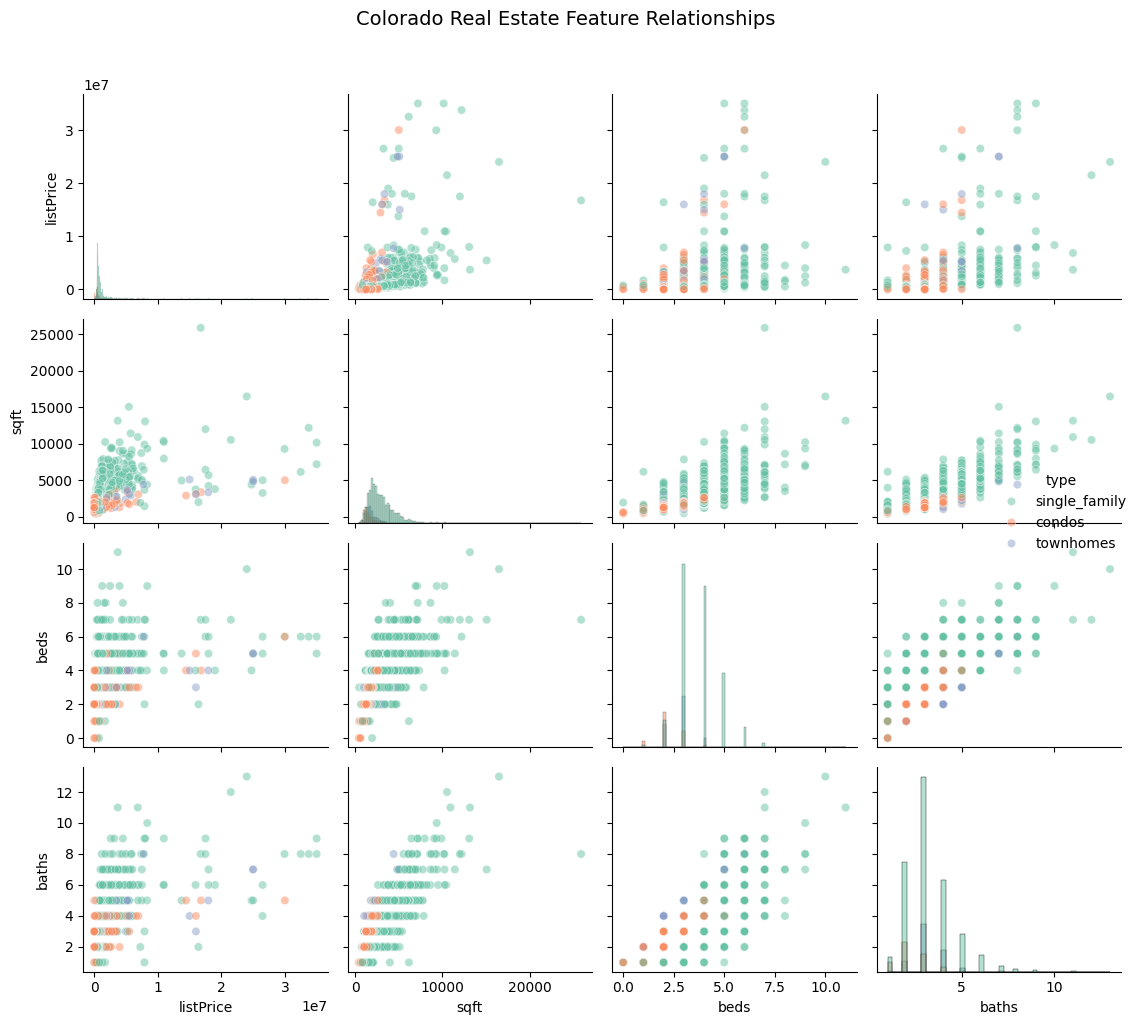

   -> Pair plot saved as 'real_estate_pairplot.png'



In [ ]:
plot_features = ['listPrice', 'sqft', 'beds', 'baths', 'type']

sns.pairplot(
    df[plot_features],
    hue='type',
    palette='Set2',
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 'edgecolor': 'w'}
)
plt.suptitle('Colorado Real Estate Feature Relationships', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('real_estate_pairplot.png', dpi=150)
plt.show()

print("   -> Pair plot saved as 'real_estate_pairplot.png'")
print()

/tmp/ipykernel_567/2086139289.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


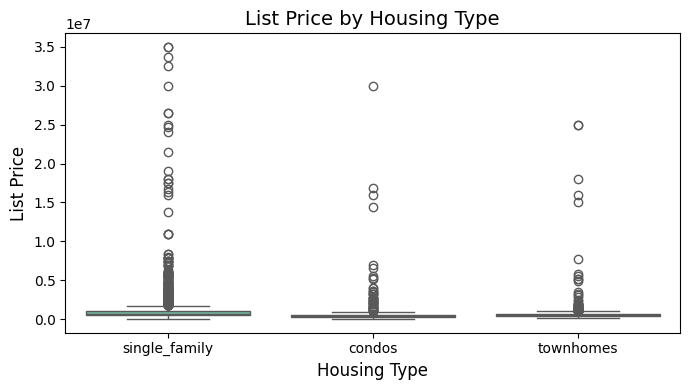

   -> Box plot saved as 'real_estate_boxplot.png'



In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x='type',
    y='listPrice',
    palette='Set2',
    order=['single_family', 'condos', 'townhomes']
)
plt.xlabel('Housing Type', fontsize=12)
plt.ylabel('List Price', fontsize=12)
plt.title('List Price by Housing Type', fontsize=14)
plt.tight_layout()
plt.savefig('real_estate_boxplot.png', dpi=150)
plt.show()

print("   -> Box plot saved as 'real_estate_boxplot.png'")
print()

In [ ]:
# ============================================================
# STEP 4: PREPARE DATA
# ============================================================
print("STEP 4: Preparing the Data")
print("-" * 40)

X = df[feature_cols]
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print()

print("Class balance check:")
print(f"  Training: {dict(y_train.value_counts())}")
print(f"  Testing:  {dict(y_test.value_counts())}")
print()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled with StandardScaler.")
print()

STEP 4: Preparing the Data
----------------------------------------
Training samples: 2724
Testing samples:  682

Class balance check:
  Training: {'single_family': np.int64(2082), 'townhomes': np.int64(369), 'condos': np.int64(273)}
  Testing:  {'single_family': np.int64(522), 'townhomes': np.int64(92), 'condos': np.int64(68)}

Features scaled with StandardScaler.



In [ ]:
# ============================================================
# STEP 5: TRAIN AND EVALUATE KNN
# ============================================================
print("STEP 5: Training and Evaluating")
print("-" * 40)

STEP 5: Training and Evaluating
----------------------------------------


In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

Overall Accuracy: 81.67%



In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

       condos       0.65      0.51      0.57        68
single_family       0.88      0.92      0.90       522
    townhomes       0.52      0.45      0.48        92

     accuracy                           0.82       682
    macro avg       0.68      0.63      0.65       682
 weighted avg       0.81      0.82      0.81       682



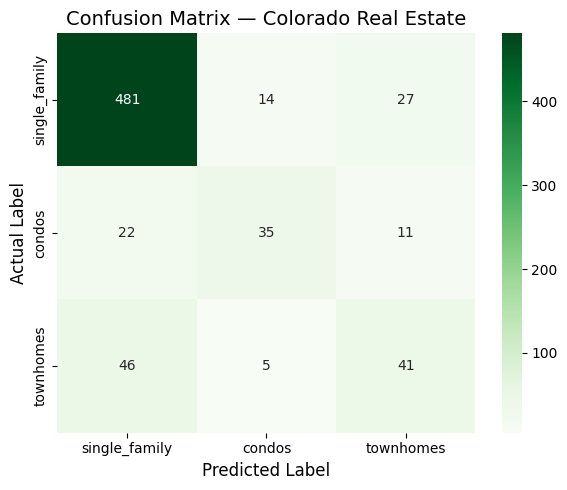

   -> Confusion matrix saved as 'real_estate_confusion.png'



In [ ]:
cm = confusion_matrix(
    y_test, y_pred,
    labels=['single_family', 'condos', 'townhomes']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['single_family', 'condos', 'townhomes'],
    yticklabels=['single_family', 'condos', 'townhomes']
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix — Colorado Real Estate', fontsize=14)
plt.tight_layout()
plt.savefig('real_estate_confusion.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'real_estate_confusion.png'")
print()

In [ ]:
# ============================================================
# STEP 6: FIND BEST K WITH CROSS-VALIDATION
# ============================================================
print("STEP 6: Finding the Best K with Cross-Validation")
print("-" * 40)

k_range = range(1, 31)
cv_means = []
cv_stds = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

    if k % 5 == 0 or k == 1:
        print(f"   K={k:2d} -> CV Accuracy = {scores.mean():.2%} (+/- {scores.std():.2%})")

print()

STEP 6: Finding the Best K with Cross-Validation
----------------------------------------
   K= 1 -> CV Accuracy = 80.76% (+/- 1.41%)
   K= 5 -> CV Accuracy = 82.78% (+/- 1.60%)
   K=10 -> CV Accuracy = 83.92% (+/- 1.17%)
   K=15 -> CV Accuracy = 83.59% (+/- 1.66%)
   K=20 -> CV Accuracy = 82.82% (+/- 1.48%)
   K=25 -> CV Accuracy = 83.04% (+/- 1.09%)
   K=30 -> CV Accuracy = 82.82% (+/- 0.65%)



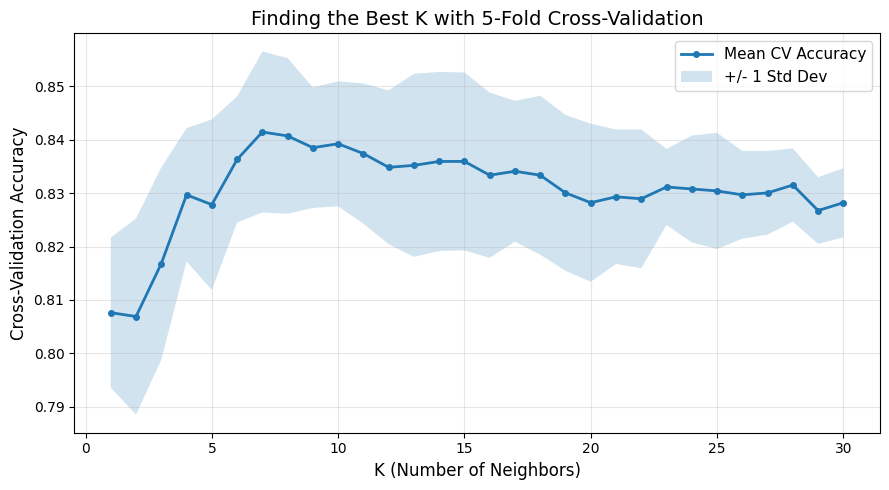

   -> Best K = 7
   -> Best CV Accuracy = 84.14%



In [ ]:
plt.figure(figsize=(9, 5))
cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
k_list = list(k_range)

plt.plot(k_list, cv_means, marker='o', linewidth=2, markersize=4, label='Mean CV Accuracy')
plt.fill_between(
    k_list,
    cv_means - cv_stds,
    cv_means + cv_stds,
    alpha=0.2,
    label='+/- 1 Std Dev'
)

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Finding the Best K with 5-Fold Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('real_estate_best_k.png', dpi=150)
plt.show()

best_k = k_list[np.argmax(cv_means)]
best_cv_accuracy = cv_means.max()

print(f"   -> Best K = {best_k}")
print(f"   -> Best CV Accuracy = {best_cv_accuracy:.2%}")
print()

In [ ]:
# ============================================================
# STEP 7: FINAL MODEL
# ============================================================
print("STEP 7: Final Evaluation with Best K")
print("-" * 40)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"Final Test Accuracy (K={best_k}): {final_accuracy:.2%}")
print()

print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

STEP 7: Final Evaluation with Best K
----------------------------------------
Final Test Accuracy (K=7): 81.67%

Final Classification Report:
               precision    recall  f1-score   support

       condos       0.65      0.51      0.57        68
single_family       0.88      0.92      0.90       522
    townhomes       0.52      0.45      0.48        92

     accuracy                           0.82       682
    macro avg       0.68      0.63      0.65       682
 weighted avg       0.81      0.82      0.81       682



In [ ]:
# ============================================================
# STEP 8: PREDICT NEW PROPERTIES
# ============================================================
print("STEP 8: Predicting New Properties")
print("-" * 40)

new_properties = pd.DataFrame({
    'listPrice':       [350000, 520000, 780000],
    'sqft':            [900, 1600, 2800],
    'stories':         [1, 2, 2],
    'beds':            [2, 3, 4],
    'baths':           [1.5, 2.5, 3.5],
    'baths_full':      [1, 2, 3],
    'baths_full_calc': [1, 2, 3],
    'garage':          [1, 2, 3]
})

print("New property measurements:")
print(new_properties.to_string(index=False))
print()

new_scaled = scaler.transform(new_properties)

predictions = final_model.predict(new_scaled)
probabilities = final_model.predict_proba(new_scaled)

class_labels = final_model.classes_

for i in range(len(new_properties)):
    print(f"Property #{i+1}:")
    print(f"   Predicted housing type: {predictions[i]}")
    print(f"   Confidence breakdown:")

    for cls, prob in zip(class_labels, probabilities[i]):
        bar_length = int(prob * 25)
        bar = '█' * bar_length + '░' * (25 - bar_length)
        print(f"      {cls:15s} {bar} {prob:6.1%}")
    print()

STEP 8: Predicting New Properties
----------------------------------------
New property measurements:
 listPrice  sqft  stories  beds  baths  baths_full  baths_full_calc  garage
    350000   900        1     2    1.5           1                1       1
    520000  1600        2     3    2.5           2                2       2
    780000  2800        2     4    3.5           3                3       3

Property #1:
   Predicted housing type: single_family
   Confidence breakdown:
      condos          ██████████░░░░░░░░░░░░░░░  42.9%
      single_family   ██████████████░░░░░░░░░░░  57.1%
      townhomes       ░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%

Property #2:
   Predicted housing type: single_family
   Confidence breakdown:
      condos          ░░░░░░░░░░░░░░░░░░░░░░░░░   0.0%
      single_family   █████████████████░░░░░░░░  71.4%
      townhomes       ███████░░░░░░░░░░░░░░░░░░  28.6%

Property #3:
   Predicted housing type: single_family
   Confidence breakdown:
      condos          ░░

# New Section
This project uses real estate data from Colorado to teach a computer how to recognize different types of homes, such as single-family houses, condos, and townhomes, based on features like price, size, number of bedrooms, and bathrooms. The program first cleans and organizes the data, then explores it to understand patterns and differences between housing types. It builds a model that compares each home to similar ones and predicts its category, testing and improving the model to make it as accurate as possible. Finally, it applies the model to new properties, predicting what type of home they are and how confident it is in those predictions. Overall, the project demonstrates how data can be used to identify patterns and make informed predictions in the real estate market.
